In [1]:
# General purpose
import numpy as np
import pandas as pd
from glob import glob

# Metrics
from cellpose_omni.metrics import average_precision

from scipy.stats import levene,f_oneway,kruskal

import matplotlib.pyplot as plt
import seaborn as sns

from skimage import io
from MEDUSSA.utils import BorderRemoval
from MEDUSSA.measure import SizeDataFrame

In [2]:
mtg_gt = sorted(glob('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS4/MTG/Selected/GT/*'))
mtg_segmented = sorted(glob('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS4/MTG/Selected/FMSeg/*'))

mtg_gt = [io.imread(mtg) for mtg in mtg_gt]
mtg_segmented = [io.imread(mtg) for mtg in mtg_segmented]

qoxB_gt = sorted(glob('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS4/QoxB/Selected/GT/*'))
qoxB_segmented = sorted(glob('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS4/QoxB/Selected/FMSeg/*'))

qoxB_gt = [io.imread(qoxB) for qoxB in qoxB_gt]
qoxB_segmented = [io.imread(qoxB) for qoxB in qoxB_segmented]



In [9]:
len(qoxB_gt)

15

In [3]:
thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1]

JI_mtg, tp, fp, fn = average_precision(mtg_gt,mtg_segmented,thresholds)
f1_mtg = 2*tp/(2*tp+fn+fp)

JI_qoxB, tp, fp, fn = average_precision(qoxB_gt,qoxB_segmented,thresholds)
f1_qoxB = 2*tp/(2*tp+fn+fp)


In [11]:
f1s = [f1_mtg,f1_qoxB]

names = ['MitoTrackerGreen','QoxB_sfGFP']#

dfs = []

for i in range(len(qoxB_gt)):

    for f,n in zip(f1s,names):
            
        df = pd.DataFrame()

        df.insert(0,'F1',f[i])
        df.insert(0,'Threshold',thresholds)
        df.insert(0,'Dye',n)
        df.insert(3,'Image',i)

        dfs.append(df)

full_df = pd.concat(dfs)
full_df.to_csv('/Users/reyesmatte/Desktop/MEDUSSA_paper/Raw_data/FigS4.csv')

In [4]:
mtg_size = SizeDataFrame(maskfilelist=mtg_segmented,from_files=False,pixsize=33.02/512)
mtg_size = mtg_size[mtg_size['Width'] > 0.3]

qoxB_size = SizeDataFrame(maskfilelist=qoxB_segmented,from_files=False,pixsize=33.02/512)
qoxB_size = qoxB_size[qoxB_size['Width'] > 0.3]

mtg_w = np.array(mtg_size['Width'])
qoxB_w = np.array(qoxB_size['Width'])

/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/reyesmatte/miniforge3/envs/omnipose/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [5]:
print(levene(mtg_w,qoxB_w))

print(f_oneway(mtg_w,qoxB_w))

print(kruskal(mtg_w,qoxB_w))

LeveneResult(statistic=np.float64(1.5836420581744526), pvalue=np.float64(0.2085526907971984))
F_onewayResult(statistic=np.float64(5.468308534833673), pvalue=np.float64(0.01957543401786397))
KruskalResult(statistic=np.float64(10.284356015540197), pvalue=np.float64(0.0013416283654146572))


2026-03-11 10:45:05,033 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-11 10:45:05,038 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-11 10:45:05,055 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-11 10:45:05,057 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-11 10:45:05,077 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or 

/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_91639/1533642761.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(labels=ax[0].get_yticklabels(),fontsize=12)
/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_91639/1533642761.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(labels=ax[0].get_xticklabels(),fontsize=12)
/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_91639/1533642761.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(labels=ax[0].get_yticklabels(),fontsize=12)
/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_91639/1533642761.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

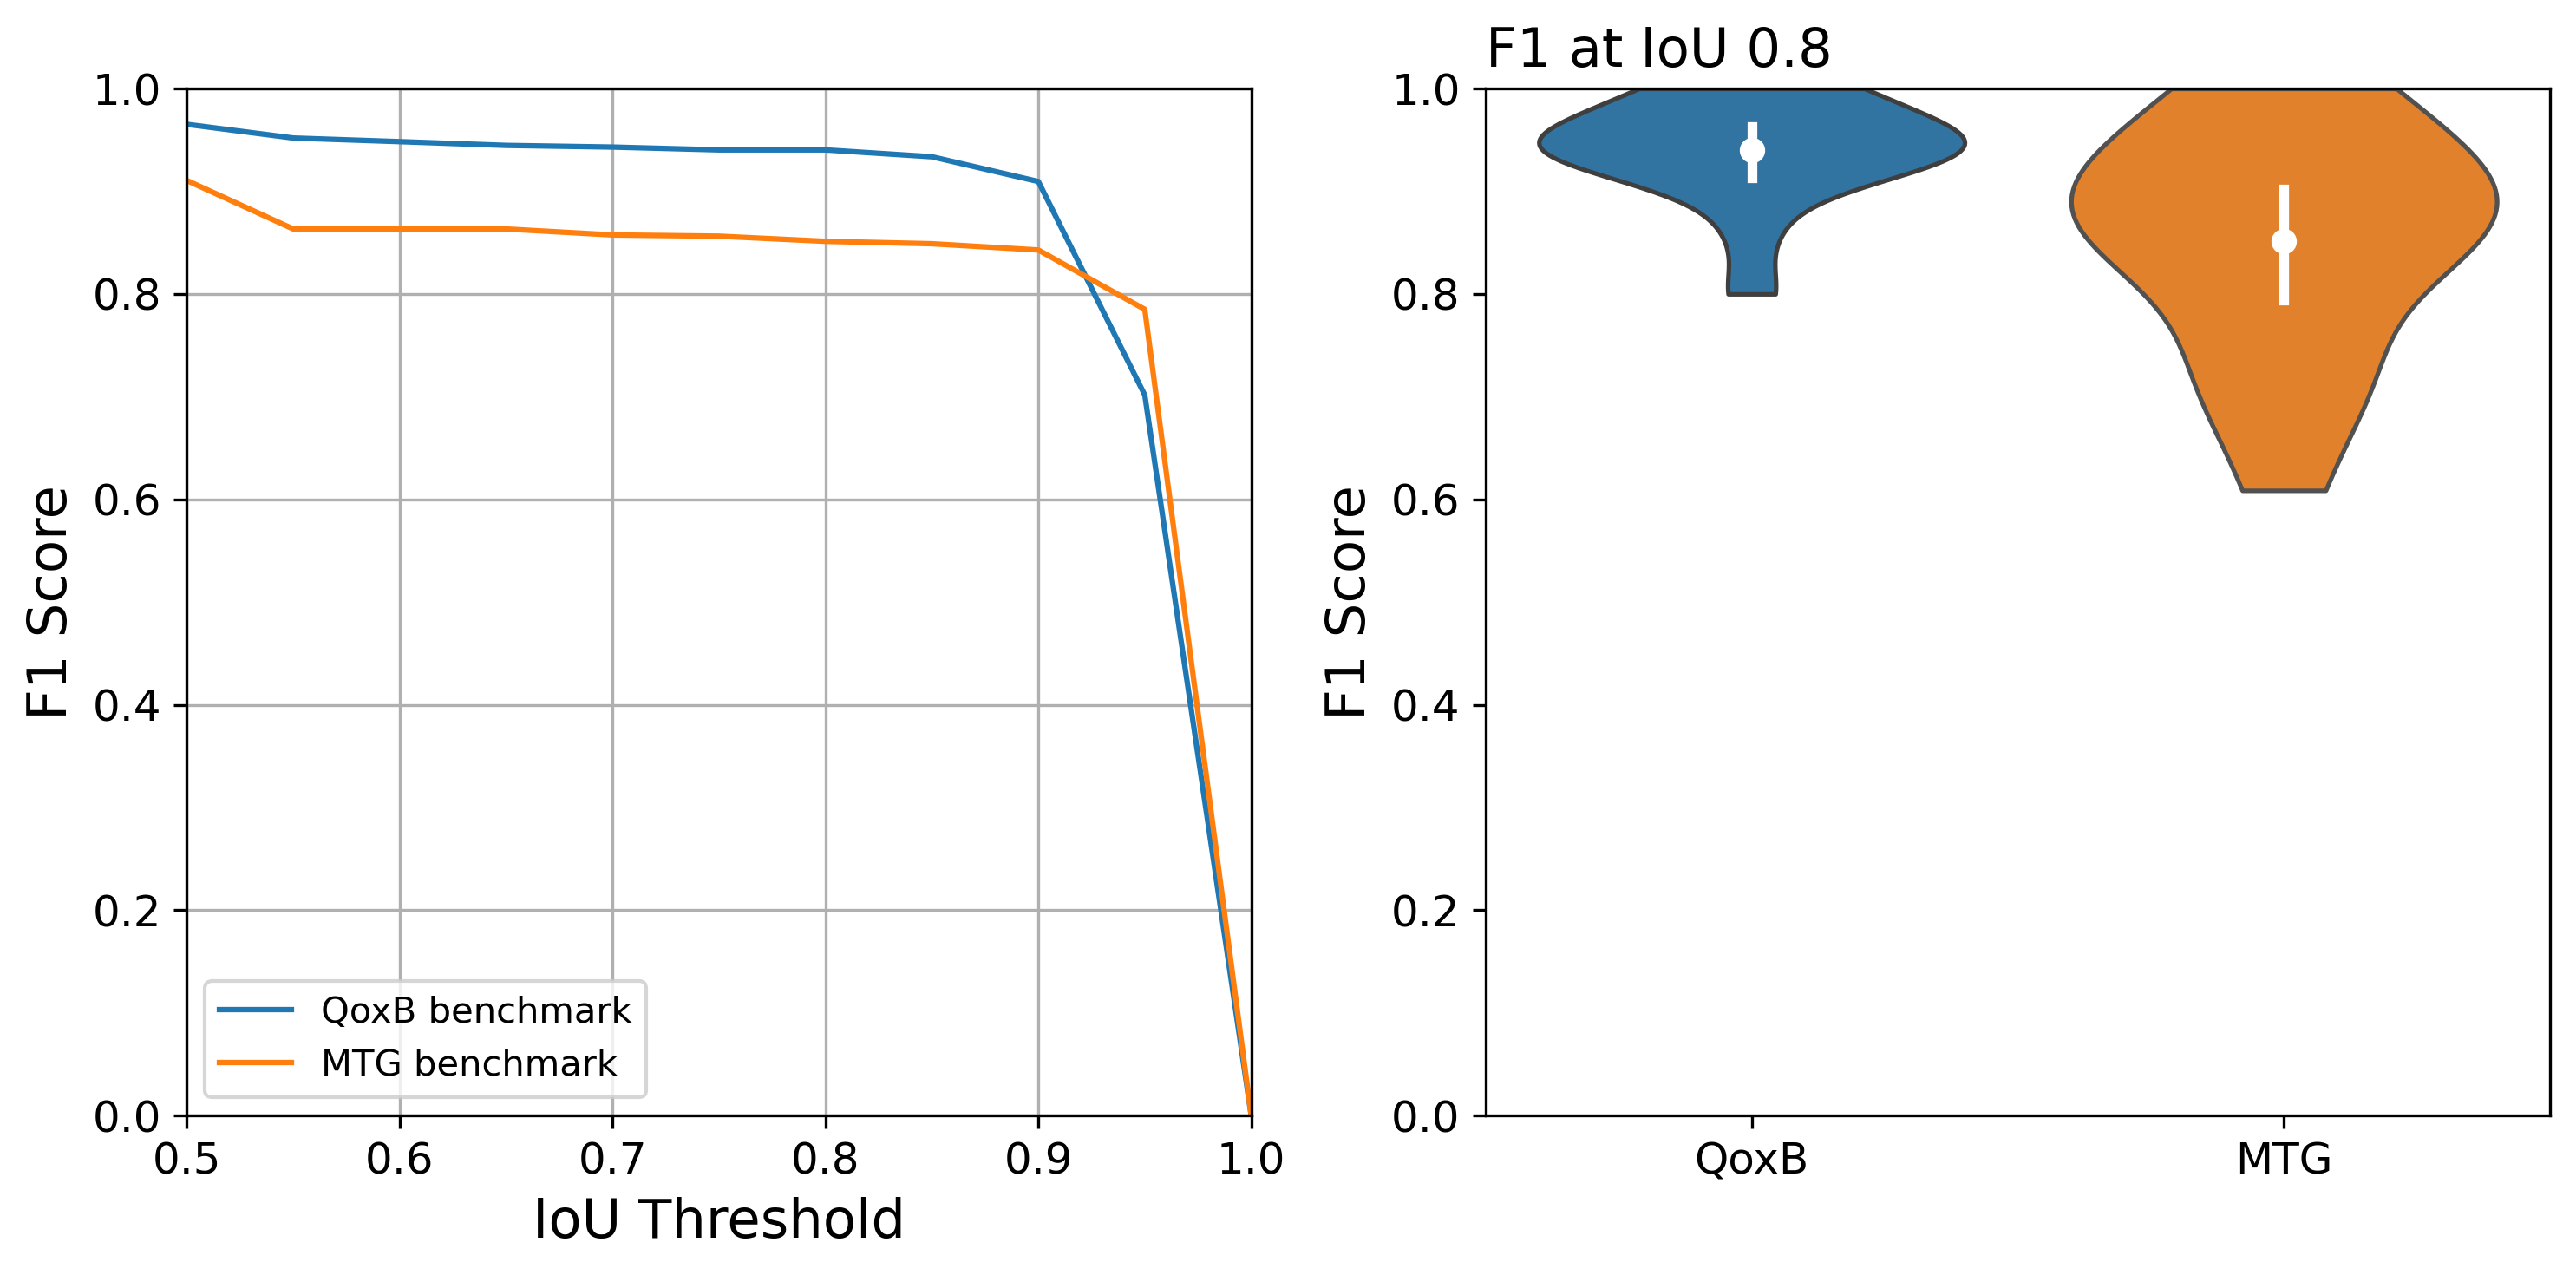

In [6]:
pval = f_oneway(mtg_w,qoxB_w)[1]

fig,ax = plt.subplots(dpi=300, figsize=(10,5), ncols=2)

ax[0].plot(thresholds,np.mean(f1_qoxB,axis=0),label='QoxB benchmark')
ax[0].plot(thresholds,np.mean(f1_mtg,axis=0),label='MTG benchmark')
ax[0].set_ylim(0,1)
ax[0].grid(visible=True,axis='both')
ax[0].set_ylabel('F1 Score',fontsize=15)
ax[0].set_yticklabels(labels=ax[0].get_yticklabels(),fontsize=12)
ax[0].set_xlabel('IoU Threshold',fontsize=15)
ax[0].set_xlim(0.5,1)
ax[0].set_xticklabels(labels=ax[0].get_xticklabels(),fontsize=12)
ax[0].legend()


sns.violinplot(x=1,y=np.array(f1_qoxB)[:,6],cut=0,inner=None,ax=ax[1])
sns.pointplot(x=1,y=np.array(f1_qoxB)[:,6],color='w',ax=ax[1],markersize=5)
sns.violinplot(x=2,y=np.array(f1_mtg)[:,6],cut=0,inner=None,ax=ax[1])
sns.pointplot(x=2,y=np.array(f1_mtg)[:,6],color='w',ax=ax[1],markersize=5)
ax[1].set_ylim(0,1)
ax[1].set_ylabel('F1 Score',fontsize=15)
ax[1].set_yticklabels(labels=ax[0].get_yticklabels(),fontsize=12)
ax[1].set_xlabel('')
ax[1].set_xticklabels(['QoxB','MTG'],fontsize=12)
ax[1].set_title('F1 at IoU 0.8', fontsize=15, loc='left')


fig.tight_layout()
fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/FigS4/F1_benchmarking.png')